In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(100)
X=np.random.rand(100,1)-0.5
y= 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

In [3]:
import pandas as pd

In [4]:
df=pd.DataFrame()

In [5]:
df['X']=X.reshape(100)
df['y']=y
df.head()

,X,y
0,0.043405,0.040158
1,-0.221631,0.181705
2,-0.075482,-0.061242
3,0.344776,0.401860
4,-0.495281,0.774851


Text(0.5, 1.0, 'X vs Y')

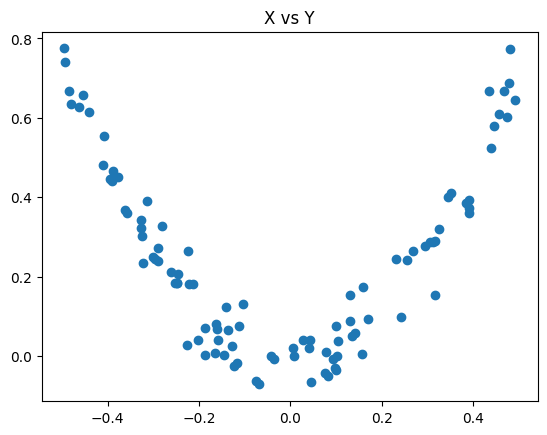

In [6]:
plt.scatter(df['X'],df['y'])
plt.title('X vs Y')

In [7]:
df['pred1']=df['y'].mean()
df.head()

,X,y,pred1
0,0.043405,0.040158,0.24599
1,-0.221631,0.181705,0.24599
2,-0.075482,-0.061242,0.24599
3,0.344776,0.401860,0.24599
4,-0.495281,0.774851,0.24599


In [8]:
df['resd1']=df['y']-df['pred1']
df.head()

,X,y,pred1,resd1
0,0.043405,0.040158,0.24599,-0.205831
1,-0.221631,0.181705,0.24599,-0.064285
2,-0.075482,-0.061242,0.24599,-0.307231
3,0.344776,0.401860,0.24599,0.155871
4,-0.495281,0.774851,0.24599,0.528862


In [9]:
from sklearn.tree import DecisionTreeRegressor,plot_tree
tree1=DecisionTreeRegressor(max_leaf_nodes=8)

In [11]:
tree1.fit(X.reshape(100, 1), df['resd1'])

DecisionTreeRegressor(max_leaf_nodes=8)

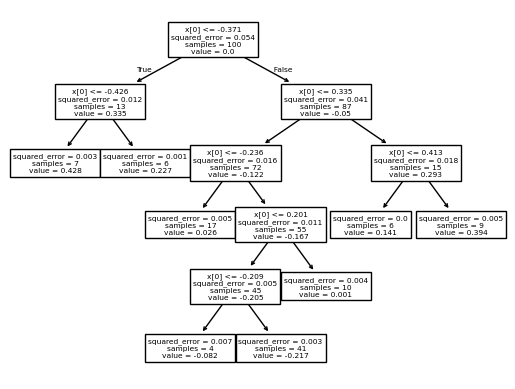

In [12]:
from sklearn.tree import plot_tree
plot_tree(tree1)
plt.show()

In [13]:
X_test= np.linspace(-0.5, 0.5, 500)

In [14]:
y_pred= 0.265458 + tree1.predict(X_test.reshape(500, 1))

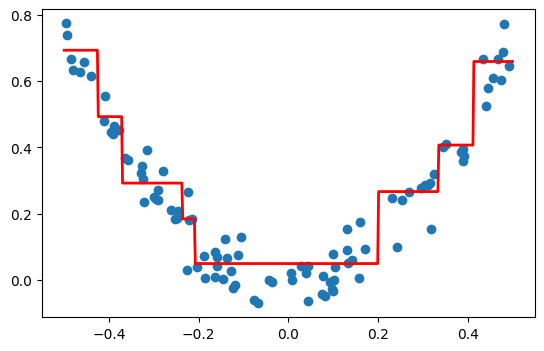

In [15]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test,y_pred, linewidth=2,color='red')
plt.scatter(df['X'],df['y'])

In [16]:
df['pred2']=0.24599+tree1.predict(df['X'].values.reshape(100,1))
df

,X,y,pred1,resd1,pred2
0,0.043405,0.040158,0.24599,-0.205831,0.029296
1,-0.221631,0.181705,0.24599,-0.064285,0.164291
2,-0.075482,-0.061242,0.24599,-0.307231,0.029296
3,0.344776,0.401860,0.24599,0.155871,0.387421
4,-0.495281,0.774851,0.24599,0.528862,0.673945
...,...,...,...,...,...
95,0.158940,0.175300,0.24599,-0.070690,0.029296
96,-0.245742,0.207318,0.24599,-0.038672,0.272468
97,0.141101,0.058911,0.24599,-0.187078,0.029296
98,-0.299876,0.248987,0.24599,0.002997,0.272468


In [20]:
df['resd2']=df['y']-df['pred2']
df.head()

,X,y,pred1,resd1,pred2,resd2
0,0.043405,0.040158,0.24599,-0.205831,0.029296,0.010862
1,-0.221631,0.181705,0.24599,-0.064285,0.164291,0.017414
2,-0.075482,-0.061242,0.24599,-0.307231,0.029296,-0.090538
3,0.344776,0.401860,0.24599,0.155871,0.387421,0.014440
4,-0.495281,0.774851,0.24599,0.528862,0.673945,0.100906


In [23]:
tree2=DecisionTreeRegressor(max_leaf_nodes=8)
tree2.fit(df['X'].values.reshape(100,1),df['resd2'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [27]:
y_pred2=0.24599+tree1.predict(X_test.reshape(500,1))+tree2.predict(X_test.reshape(500,1))

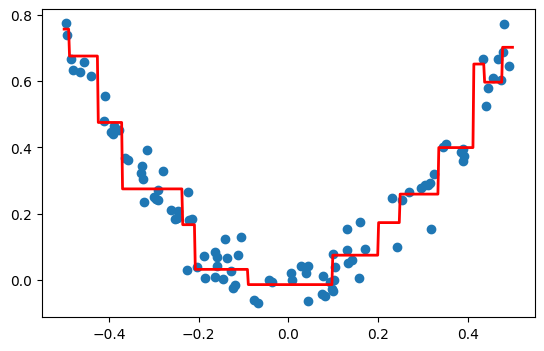

In [28]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test,y_pred2, linewidth=2,color='red')
plt.scatter(df['X'],df['y'])

## ADDITIVE MODELING

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
data=[[165.0,137.0,472.0,192.0],
     [101.0,92.0,250.0,144.0],
     [29.0,127.0,201.0,91.0]]
df=pd.DataFrame(data,columns=['R&D Spend','Admistration','Marketing Spend','Profit'])
df

,R&D Spend,Admistration,Marketing Spend,Profit
0,165.0,137.0,472.0,192.0
1,101.0,92.0,250.0,144.0
2,29.0,127.0,201.0,91.0


In [6]:
df['f0(X)']=df['Profit'].mean()
df

,R&D Spend,Admistration,Marketing Spend,Profit,f0(X)
0,165.0,137.0,472.0,192.0,142.333333
1,101.0,92.0,250.0,144.0,142.333333
2,29.0,127.0,201.0,91.0,142.333333


In [12]:
df['ri1']=df['Profit']-df['f0(X)']
df

,R&D Spend,Admistration,Marketing Spend,Profit,f0(X),ri1
0,165.0,137.0,472.0,192.0,142.333333,49.666667
1,101.0,92.0,250.0,144.0,142.333333,1.666667
2,29.0,127.0,201.0,91.0,142.333333,-51.333333


In [21]:
from sklearn.tree import DecisionTreeRegressor
dt1=DecisionTreeRegressor(max_depth=1)

In [22]:
dt1.fit(df.iloc[:,0:3].values,df.iloc[:,-1].values)

DecisionTreeRegressor(max_depth=1)

<function matplotlib.pyplot.show(close=None, block=None)>

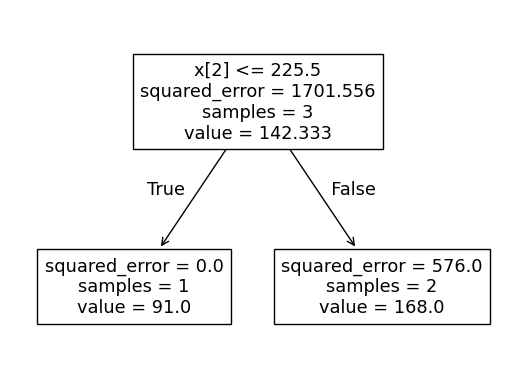

In [23]:
from sklearn.tree import plot_tree
plot_tree(dt1)
plt.show